<a href="https://colab.research.google.com/github/Tushar5687/Carbon-Track/blob/main/Mines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mines.csv to mines.csv


In [ ]:
df = pd.read_csv('mines.csv')
df.head()

,diesel,electricity,methane,transport,mine_type,emission
0,120,800,5,12,gold,450
1,150,900,6,15,gold,500
2,200,1100,8,18,iron,650
3,250,1300,10,20,iron,750
4,300,1500,12,22,coal,900


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df.columns

Index(['diesel', 'electricity', 'methane', 'transport', 'mine_type',
       'emission'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   diesel       82 non-null     int64 
 1   electricity  82 non-null     int64 
 2   methane      82 non-null     int64 
 3   transport    82 non-null     int64 
 4   mine_type    82 non-null     object
 5   emission     82 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 4.0+ KB


In [ ]:
X = df[['diesel', 'electricity', 'methane', 'transport', 'mine_type']]
y = df['emission']


In [ ]:
X = pd.get_dummies(X, columns=['mine_type'])

In [ ]:
X.head()

,diesel,electricity,methane,transport,mine_type_coal,mine_type_gold,mine_type_iron
0,120,800,5,12,False,True,False
1,150,900,6,15,False,True,False
2,200,1100,8,18,False,False,True
3,250,1300,10,20,False,False,True
4,300,1500,12,22,True,False,False


In [ ]:
X['mine_type_coal'] = X['mine_type_coal'].astype(int)
X['mine_type_gold'] = X['mine_type_gold'].astype(int)
X['mine_type_iron'] = X['mine_type_iron'].astype(int)


In [ ]:
X.head()

,diesel,electricity,methane,transport,mine_type_coal,mine_type_gold,mine_type_iron
0,120,800,5,12,0,1,0
1,150,900,6,15,0,1,0
2,200,1100,8,18,0,0,1
3,250,1300,10,20,0,0,1
4,300,1500,12,22,1,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)



RandomForestRegressor()

In [ ]:


# Prediction
y_pred= model.predict(X_test)

In [ ]:
y_pred

array([1806.7, 2583.8, 2069.3, 2708.6,  711.7, 2224.4, 1026. , 1355.2,
        666.3, 1200. ,  884.8, 1383.9, 2004.7,  600.4,  488.4, 1949. ,
        481.2])

In [ ]:
y_test.head()

,emission
36,1800
54,2600
11,2100
14,2700
57,720


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.9992908817828434
MAE: 15.105882352941144
RMSE: 19.27854644264383


In [ ]:
# High R² (~0.8–0.95) → strong model
# Low MAE/RMSE → predictions are close to actual values
# Compare metrics with a baseline model (like mean prediction)

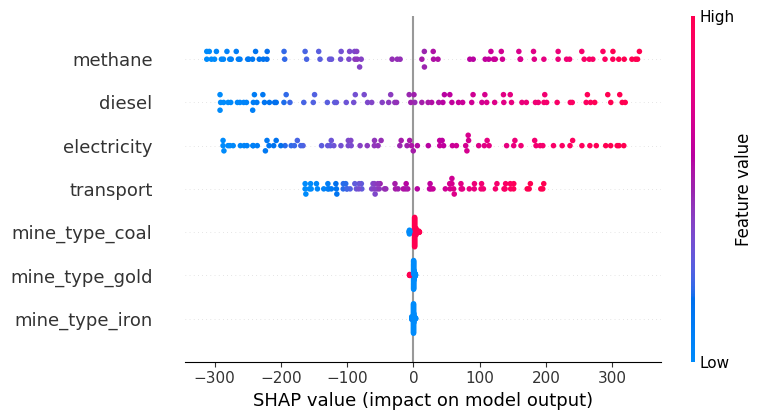

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

In [ ]:
# SHAP values (for all samples)
shap_vals = np.abs(shap_values)

# Average contribution per feature
mean_contrib = np.mean(shap_vals, axis=0)

# Convert to percentage
percent_contrib = 100 * mean_contrib / np.sum(mean_contrib)

result = pd.DataFrame({
    "feature": X.columns,
    "contribution_%": percent_contrib
}).sort_values(by="contribution_%", ascending=False)

print(result)

          feature  contribution_%
2         methane       31.219548
0          diesel       26.443054
1     electricity       25.733262
3       transport       15.607636
4  mine_type_coal        0.631974
5  mine_type_gold        0.238913
6  mine_type_iron        0.125613


In [ ]:
# def explain_mine(row):
#     pred = model.predict(row)[0]
#     shap_vals = explainer.
#shap_values(row)
#     return pred, shap_vals

In [ ]:
''' But here’s the important reality: you can’t directly “run a Colab model” inside Node.js. You need to export it and serve it properly. Let’s go step-by-step in a practical way.
✅ Step 1: Save your trained model from Colab
Depending on what you used:
👉 If you used Scikit-learn / Random Forest
Python
import joblib

joblib.dump(model, "model.pkl")
Download the .pkl file.
✅ Step 2: Create a Python API (Flask or FastAPI)
Node.js cannot directly use .pkl, so you create a small Python service.
Example using Flask:
Python
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)
model = joblib.load("model.pkl")

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json['input']  # input should be a list
    prediction = model.predict([data])
    return jsonify({'prediction': prediction.tolist()})

if __name__ == '__main__':
    app.run(port=5000)
Run this → your ML model is now an API:

http://localhost:5000/predict
✅ Step 3: Connect Express.js to your ML API
Now your Express.js backend will call the Python API.
Install axios:
Bash
npm install axios
Example route in Express:
JavaScript
const express = require("express");
const axios = require("axios");

const app = express();
app.use(express.json());

app.post("/predict", async (req, res) => {
  try {
    const response = await axios.post("http://localhost:5000/predict", {
      input: req.body.input
    });

    res.json(response.data);
  } catch (error) {
    res.status(500).send("Error in prediction");
  }
});

app.listen(3000, () => console.log("Server running on port 3000"));
✅ Step 4: Flow of your system

Frontend → Express.js → Python ML API → Model → Prediction → Back '''


' But here’s the important reality: you can’t directly “run a Colab model” inside Node.js. You need to export it and serve it properly. Let’s go step-by-step in a practical way.\n✅ Step 1: Save your trained model from Colab\nDepending on what you used:\n👉 If you used Scikit-learn / Random Forest\nPython\nimport joblib\n\njoblib.dump(model, "model.pkl")\nDownload the .pkl file.\n✅ Step 2: Create a Python API (Flask or FastAPI)\nNode.js cannot directly use .pkl, so you create a small Python service.\nExample using Flask:\nPython\nfrom flask import Flask, request, jsonify\nimport joblib\n\napp = Flask(__name__)\nmodel = joblib.load("model.pkl")\n\n@app.route(\'/predict\', methods=[\'POST\'])\ndef predict():\n    data = request.json[\'input\']  # input should be a list\n    prediction = model.predict([data])\n    return jsonify({\'prediction\': prediction.tolist()})\n\nif __name__ == \'__main__\':\n    app.run(port=5000)\nRun this → your ML model is now an API:\n\nhttp://localhost:5000/pre